# Add-ons da Regressão Logística num Conjunto de Dados Desequilibrado

Usei este notebook para testar os add-ons num só conjunto de dados antes de correr o script maior. A ideia aqui é ver o comportamento com clareza, não tirar uma conclusão final a partir de uma única divisão dos dados.

No projecto uso a seguinte convenção:

- `target = 1` é a classe minoritária, tratada como a classe positiva.
- `target = 0` é a classe maioritária, tratada como a classe negativa.
- A accuracy aparece nos resultados, mas dou mais importância à balanced accuracy, ao recall da classe minoritária e ao F1 da classe minoritária.

## 1. Preparação

Esta célula só define os caminhos e algumas opções dos gráficos. A variável `DATASET_NAME`, mais abaixo, controla qual é o loader usado.

In [23]:
from pathlib import Path
import importlib
import pickle
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebook_runs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC_DIR.resolve()))

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 80)

In [ ]:
import datasets as dataset_module
dataset_module = importlib.reload(dataset_module)
from logistic_regression import CAGD, F1Threshold, Gaar, LogisticRegression, WeightedErrors
from metrics import BinaryClassImbalanceMetrics, safe_division

DATASET_NAME = "df5"
RANDOM_STATE = 42
LEARNING_RATE = 0.01
ITERATIONS = 1000

ARTIFACT_PATH = OUTPUT_DIR / f"{DATASET_NAME}_logistic_regression_run.pkl"

## 2. Carregar o Conjunto de Dados

Os loaders já devolvem atributos numéricos e uma coluna `target` binária. Começo pelas contagens das classes porque o desequilíbrio é a principal razão para testar estes add-ons.

Dataset: df18
Rows: 365
Features: 4
Minority ratio: 8.49%


,Lottery.pick.1970,Lottery.pick.1971,Month,Month.ordered.picks.1970,target
0,1.149972,-0.474536,-1.597591,0.720420,0
1,-0.231887,0.113889,-1.597591,-0.728337,0
2,0.638874,1.452081,-1.597591,1.589675,0
3,0.298141,-0.797221,-1.597591,-1.307840,0
4,-0.780845,-1.423609,-1.597591,1.010172,0


,count
target,
0,334
1,31


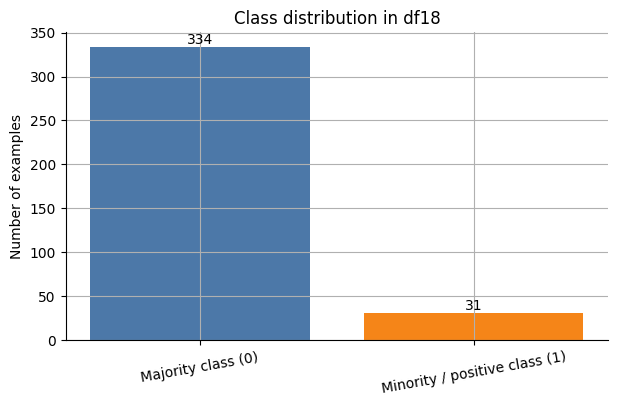

In [25]:
loader = getattr(dataset_module, DATASET_NAME)
df = loader()

feature_columns = [column for column in df.columns if column != "target"]
target_counts = df["target"].value_counts().sort_index()
minority_ratio = target_counts.get(1, 0) / len(df)

print(f"Dataset: {DATASET_NAME}")
print(f"Rows: {len(df)}")
print(f"Features: {len(feature_columns)}")
print(f"Minority ratio: {minority_ratio:.2%}")

display(df.head())
display(target_counts.rename("count").to_frame())

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4C78A8", "#F58518"]
labels = ["Majority class (0)", "Minority / positive class (1)"]
ax.bar(labels, [target_counts.get(0, 0), target_counts.get(1, 0)], color=colors)
ax.set_title(f"Class distribution in {DATASET_NAME}")
ax.set_ylabel("Number of examples")
for index, value in enumerate([target_counts.get(0, 0), target_counts.get(1, 0)]):
    ax.text(index, value, str(value), ha="center", va="bottom")
plt.xticks(rotation=10)
plt.show()

## 3. Divisão em Treino / Validação / Teste

Uso a mesma divisão ao longo de todo o notebook:

- Primeiro retiro 80% do conjunto de dados para treino+validação.
- Depois, 20% dessa parte passa a ser validação.
- Os 20% que ficaram de fora no início são usados para teste.

A validação só é usada pelo `F1Threshold`. Os resultados finais vêm do conjunto de teste.

,split,rows,class_0,class_1,minority_ratio
0,train,234,214,20,0.085470
1,validation,58,53,5,0.086207
2,test,73,67,6,0.082192


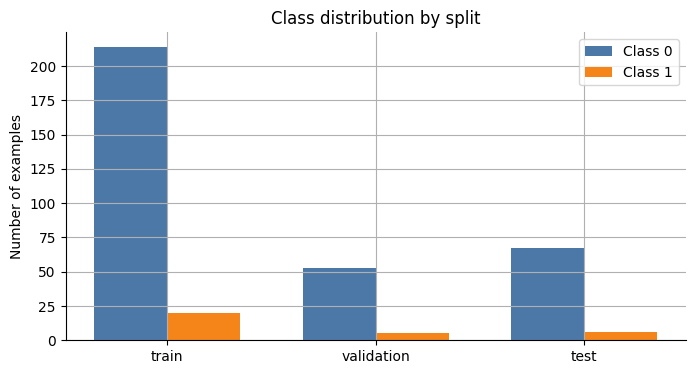

In [26]:
def train_validation_test_split(df, random_state=42):
    train = df.sample(frac=0.8, random_state=random_state)
    test = df.drop(train.index)
    validation = train.sample(frac=0.2, random_state=random_state)
    train = train.drop(validation.index)

    return {
        "frames": {
            "train": train,
            "validation": validation,
            "test": test,
        },
        "arrays": {
            "X_train": train.drop(columns=["target"]).values.astype(float),
            "y_train": train["target"].values.astype(float),
            "X_val": validation.drop(columns=["target"]).values.astype(float),
            "y_val": validation["target"].values.astype(float),
            "X_test": test.drop(columns=["target"]).values.astype(float),
            "y_test": test["target"].values.astype(float),
        },
    }

splits = train_validation_test_split(df, RANDOM_STATE)
arrays = splits["arrays"]

split_summary = []
for split_name, split_df in splits["frames"].items():
    counts = split_df["target"].value_counts().sort_index()
    split_summary.append(
        {
            "split": split_name,
            "rows": len(split_df),
            "class_0": int(counts.get(0, 0)),
            "class_1": int(counts.get(1, 0)),
            "minority_ratio": counts.get(1, 0) / len(split_df),
        }
    )

split_summary_df = pd.DataFrame(split_summary)
display(split_summary_df)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(split_summary_df))
width = 0.35
ax.bar(x - width / 2, split_summary_df["class_0"], width, label="Class 0", color="#4C78A8")
ax.bar(x + width / 2, split_summary_df["class_1"], width, label="Class 1", color="#F58518")
ax.set_xticks(x)
ax.set_xticklabels(split_summary_df["split"])
ax.set_title("Class distribution by split")
ax.set_ylabel("Number of examples")
ax.legend()
plt.show()

## 4. Variantes do Modelo

Todos os modelos usam a mesma classe de regressão logística e os mesmos hiperparâmetros. A única coisa que muda é a lista de add-ons.

O modelo `default` é a baseline. Para cada combinação de add-ons, verifico se ajuda a classe minoritária sem piorar demasiado a classe maioritária.

In [27]:
def build_model_specs():
    def model(addons=None):
        return LogisticRegression(
            learning_rate=LEARNING_RATE,
            iterations=ITERATIONS,
            addons=addons,
        )

    return [
        {
            "name": "default",
            "display_name": "Default",
            "addons": "None",
            "factory": lambda: model(),
        },
        {
            "name": "gaar",
            "display_name": "GAAR",
            "addons": "GAAR",
            "factory": lambda: model([Gaar(lambda_=0.01, c_minority=25.0)]),
        },
        {
            "name": "focal_loss",
            "display_name": "Focal loss",
            "addons": "WeightedErrors",
            "factory": lambda: model([WeightedErrors(gamma=2.0, alpha=0.5)]),
        },
        {
            "name": "f1_threshold",
            "display_name": "F1 threshold",
            "addons": "F1Threshold",
            "factory": lambda: model([F1Threshold()]),
        },
        {
            "name": "gaar_focal_loss",
            "display_name": "GAAR + Focal",
            "addons": "GAAR, WeightedErrors",
            "factory": lambda: model([WeightedErrors(gamma=2.0, alpha=0.5), Gaar(lambda_=0.01, c_minority=25.0)]),
        },
        {
            "name": "gaar_f1_threshold",
            "display_name": "GAAR + F1 threshold",
            "addons": "GAAR, F1Threshold",
            "factory": lambda: model([Gaar(lambda_=0.01, c_minority=25.0), F1Threshold()]),
        },
        {
            "name": "focal_loss_f1_threshold",
            "display_name": "Focal + F1 threshold",
            "addons": "WeightedErrors, F1Threshold",
            "factory": lambda: model([WeightedErrors(gamma=2.0, alpha=0.5), F1Threshold()]),
        },
        {
            "name": "gaar_focal_loss_f1_threshold",
            "display_name": "GAAR + Focal + F1",
            "addons": "GAAR, WeightedErrors, F1Threshold",
            "factory": lambda: model([WeightedErrors(gamma=2.0, alpha=0.5), Gaar(lambda_=0.01, c_minority=25.0), F1Threshold()]),
        },
        {
            "name": "cagd",
            "display_name": "CAGD",
            "addons": "CAGD",
            "factory": lambda: model([CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal")]),
        },
        {
            "name": "gaar_cagd",
            "display_name": "GAAR + CAGD",
            "addons": "GAAR, CAGD",
            "factory": lambda: model([Gaar(lambda_=0.01, c_minority=25.0), CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal")]),
        },
        {
            "name": "focal_loss_cagd",
            "display_name": "Focal + CAGD",
            "addons": "WeightedErrors, CAGD",
            "factory": lambda: model([WeightedErrors(gamma=2.0, alpha=0.5), CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal")]),
        },
        {
            "name": "cagd_f1_threshold",
            "display_name": "CAGD + F1 threshold",
            "addons": "CAGD, F1Threshold",
            "factory": lambda: model([CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal"), F1Threshold()]),
        },
        {
            "name": "gaar_focal_loss_cagd",
            "display_name": "GAAR + Focal + CAGD",
            "addons": "GAAR, WeightedErrors, CAGD",
            "factory": lambda: model([WeightedErrors(gamma=2.0, alpha=0.5), Gaar(lambda_=0.01, c_minority=25.0), CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal")]),
        },
        {
            "name": "gaar_cagd_f1_threshold",
            "display_name": "GAAR + CAGD + F1",
            "addons": "GAAR, CAGD, F1Threshold",
            "factory": lambda: model([Gaar(lambda_=0.01, c_minority=25.0), CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal"), F1Threshold()]),
        },
        {
            "name": "focal_loss_cagd_f1_threshold",
            "display_name": "Focal + CAGD + F1",
            "addons": "WeightedErrors, CAGD, F1Threshold",
            "factory": lambda: model([WeightedErrors(gamma=2.0, alpha=0.5), CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal"), F1Threshold()]),
        },
        {
            "name": "gaar_focal_loss_cagd_f1_threshold",
            "display_name": "All add-ons",
            "addons": "GAAR, WeightedErrors, CAGD, F1Threshold",
            "factory": lambda: model([WeightedErrors(gamma=2.0, alpha=0.5), Gaar(lambda_=0.01, c_minority=25.0), CAGD(alpha=5.0, epsilon=1e-2, approximation="diagonal"), F1Threshold()]),
        },
    ]

model_specs = build_model_specs()
model_overview = pd.DataFrame(
    [{"model": spec["display_name"], "add-ons": spec["addons"]} for spec in model_specs]
)
display(model_overview)

,model,add-ons
0,Default,None
1,GAAR,GAAR
2,Focal loss,WeightedErrors
3,F1 threshold,F1Threshold
4,GAAR + Focal,"GAAR, WeightedErrors"
5,GAAR + F1 threshold,"GAAR, F1Threshold"
6,Focal + F1 threshold,"WeightedErrors, F1Threshold"
7,GAAR + Focal + F1,"GAAR, WeightedErrors, F1Threshold"
8,CAGD,CAGD
9,GAAR + CAGD,"GAAR, CAGD"


## 5. Treinar e Avaliar

Cada modelo recebe os mesmos dados de treino, validação e teste. Guardo as previsões e as probabilidades porque são úteis para os gráficos seguintes.

In [28]:
def minority_precision_recall_f1(metric_object):
    precision = safe_division(metric_object.tp, metric_object.tp + metric_object.fp)
    recall = metric_object.minority_recall()
    f1 = safe_division(2 * precision * recall, precision + recall)
    return precision, recall, f1


trained_models = {}
predictions = {}
probabilities = {}
records = []

for spec in model_specs:
    print(f"Training {spec['display_name']}...")
    model = spec["factory"]()
    start = time.perf_counter()

    try:
        model.fit(
            arrays["X_train"],
            arrays["y_train"],
            arrays["X_val"],
            arrays["y_val"],
        )
        training_time = time.perf_counter() - start

        y_probability = model.predict_proba(arrays["X_test"])
        y_prediction = model.predict(arrays["X_test"])
        metric_object = BinaryClassImbalanceMetrics(arrays["y_test"], y_prediction)
        precision, recall, f1 = minority_precision_recall_f1(metric_object)

        trained_models[spec["name"]] = model
        predictions[spec["name"]] = y_prediction
        probabilities[spec["name"]] = y_probability

        records.append(
            {
                "model": spec["name"],
                "display_name": spec["display_name"],
                "status": "ok",
                "training_time_seconds": training_time,
                "threshold": model.threshold,
                "threshold_score": model.threshold_score,
                "accuracy": metric_object.accuracy(),
                "majority_baseline_accuracy": metric_object.majority_baseline_accuracy(),
                "accuracy_gain_over_majority": metric_object.accuracy_gain_over_majority(),
                "balanced_accuracy": metric_object.balanced_accuracy(),
                "majority_recall": metric_object.majority_recall(),
                "minority_recall": recall,
                "minority_precision": precision,
                "minority_f1": f1,
                "minority_error_rate": metric_object.minority_error_rate(),
                "tn": metric_object.tn,
                "fp": metric_object.fp,
                "fn": metric_object.fn,
                "tp": metric_object.tp,
            }
        )
    except Exception as exc:
        training_time = time.perf_counter() - start
        records.append(
            {
                "model": spec["name"],
                "display_name": spec["display_name"],
                "status": "error",
                "training_time_seconds": training_time,
                "error": f"{type(exc).__name__}: {exc}",
            }
        )
        print(f"  Error: {type(exc).__name__}: {exc}")

results_df = pd.DataFrame(records)
successful_results = results_df[results_df["status"] == "ok"].copy()

ranking_columns = [
    "display_name",
    "balanced_accuracy",
    "minority_recall",
    "minority_precision",
    "minority_f1",
    "accuracy_gain_over_majority",
    "training_time_seconds",
    "threshold",
]

ranking_df = successful_results.sort_values(
    ["balanced_accuracy", "minority_f1"], ascending=False
)[ranking_columns]

display(ranking_df.round(4))

Training Default...
Training GAAR...
Training Focal loss...
Training F1 threshold...
Training GAAR + Focal...
Training GAAR + F1 threshold...
Training Focal + F1 threshold...
Training GAAR + Focal + F1...
Training CAGD...
Training GAAR + CAGD...
Training Focal + CAGD...
Training CAGD + F1 threshold...
Training GAAR + Focal + CAGD...
Training GAAR + CAGD + F1...
Training Focal + CAGD + F1...
Training All add-ons...


,display_name,balanced_accuracy,minority_recall,minority_precision,minority_f1,accuracy_gain_over_majority,training_time_seconds,threshold
3,F1 threshold,0.5,1.0,0.0822,0.1519,-0.8356,0.0577,0.0100
5,GAAR + F1 threshold,0.5,1.0,0.0822,0.1519,-0.8356,0.1239,0.0100
6,Focal + F1 threshold,0.5,1.0,0.0822,0.1519,-0.8356,0.0984,0.3961
7,GAAR + Focal + F1,0.5,1.0,0.0822,0.1519,-0.8356,0.1534,0.0100
11,CAGD + F1 threshold,0.5,1.0,0.0822,0.1519,-0.8356,0.2126,0.0100
13,GAAR + CAGD + F1,0.5,1.0,0.0822,0.1519,-0.8356,0.2436,0.0694
14,Focal + CAGD + F1,0.5,1.0,0.0822,0.1519,-0.8356,0.1801,0.0100
15,All add-ons,0.5,1.0,0.0822,0.1519,-0.8356,0.2557,0.0100
0,Default,0.5,0.0,0.0000,0.0000,0.0000,0.0871,0.5000
1,GAAR,0.5,0.0,0.0000,0.0000,0.0000,0.1201,0.5000


## 6. Comparação Visual das Métricas

Estas são as métricas que usei mais na comparação das corridas. A balanced accuracy evita que a classe maioritária domine a pontuação, e o recall/F1 da classe minoritária mostra se o modelo está mesmo a encontrar a classe rara.

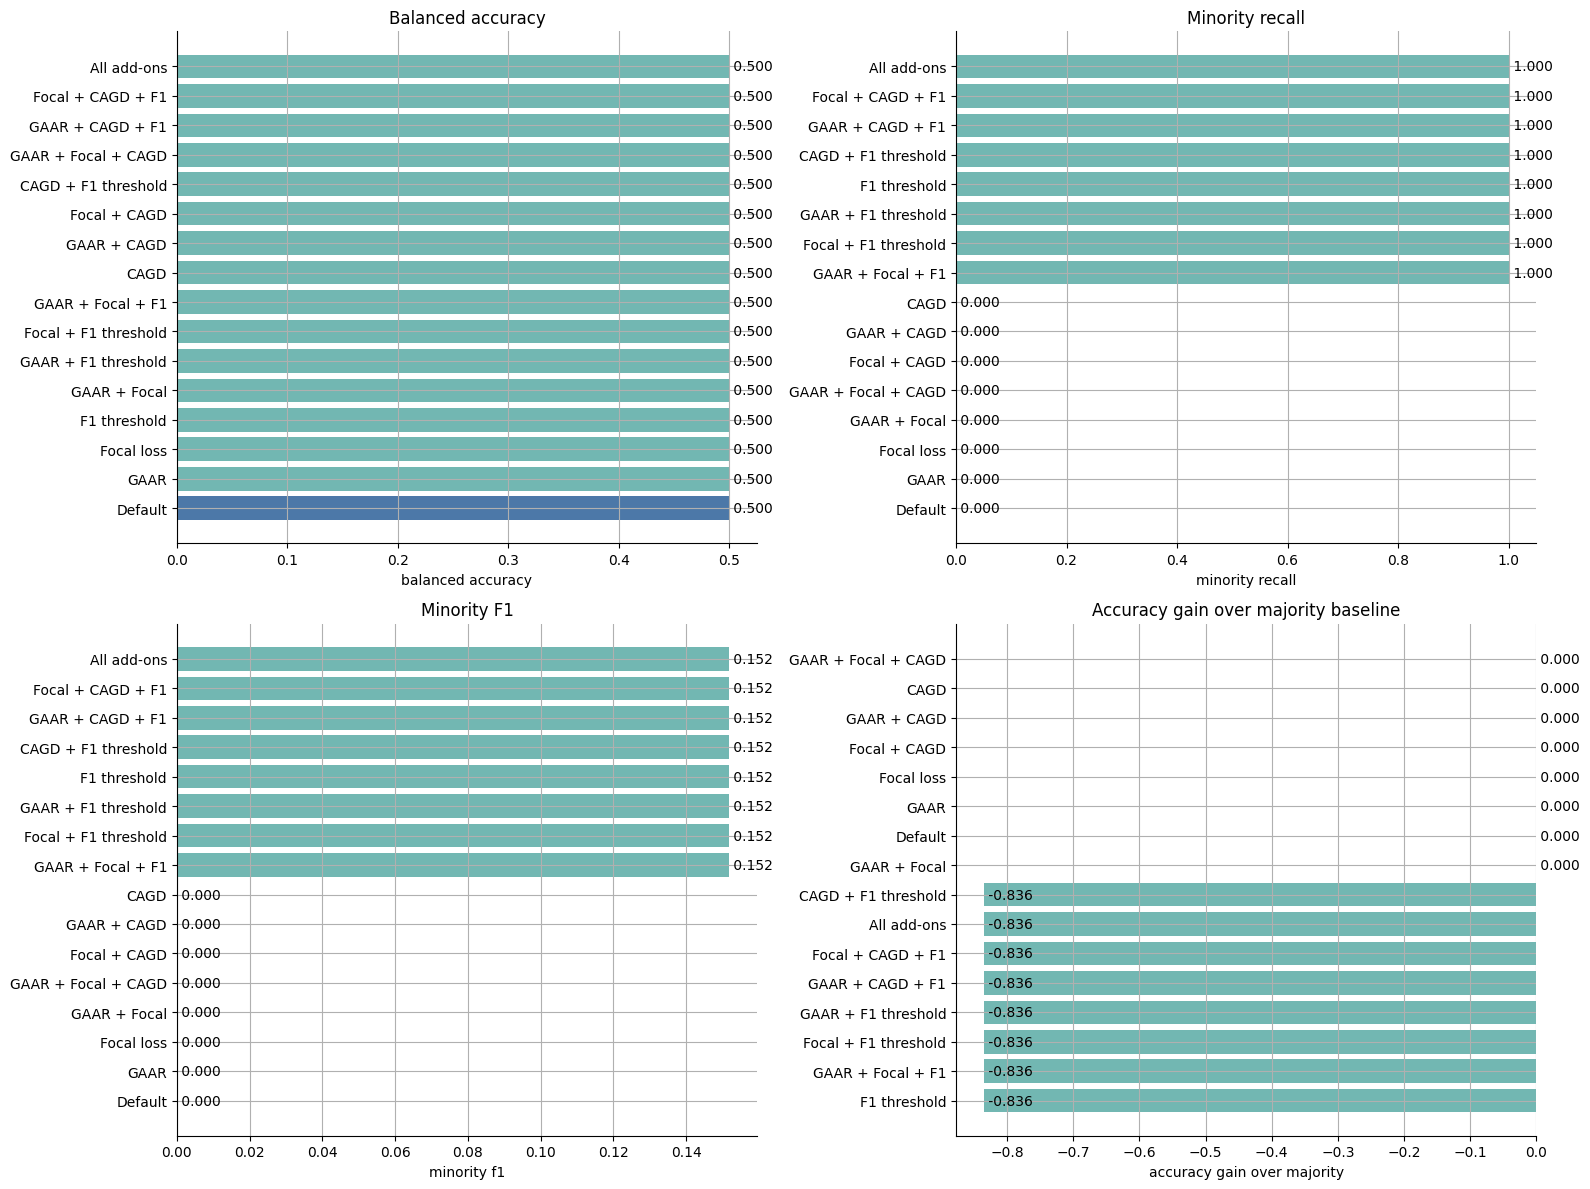

In [29]:
def plot_metric_bar(metric, title, ax):
    plot_df = successful_results.sort_values(metric, ascending=True)
    colors = ["#72B7B2" if name != "Default" else "#4C78A8" for name in plot_df["display_name"]]
    ax.barh(plot_df["display_name"], plot_df[metric], color=colors)
    ax.set_title(title)
    ax.set_xlabel(metric.replace("_", " "))
    for index, value in enumerate(plot_df[metric]):
        ax.text(value, index, f" {value:.3f}", va="center")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plot_metric_bar("balanced_accuracy", "Balanced accuracy", axes[0, 0])
plot_metric_bar("minority_recall", "Minority recall", axes[0, 1])
plot_metric_bar("minority_f1", "Minority F1", axes[1, 0])
plot_metric_bar("accuracy_gain_over_majority", "Accuracy gain over majority baseline", axes[1, 1])
plt.tight_layout()
plt.show()

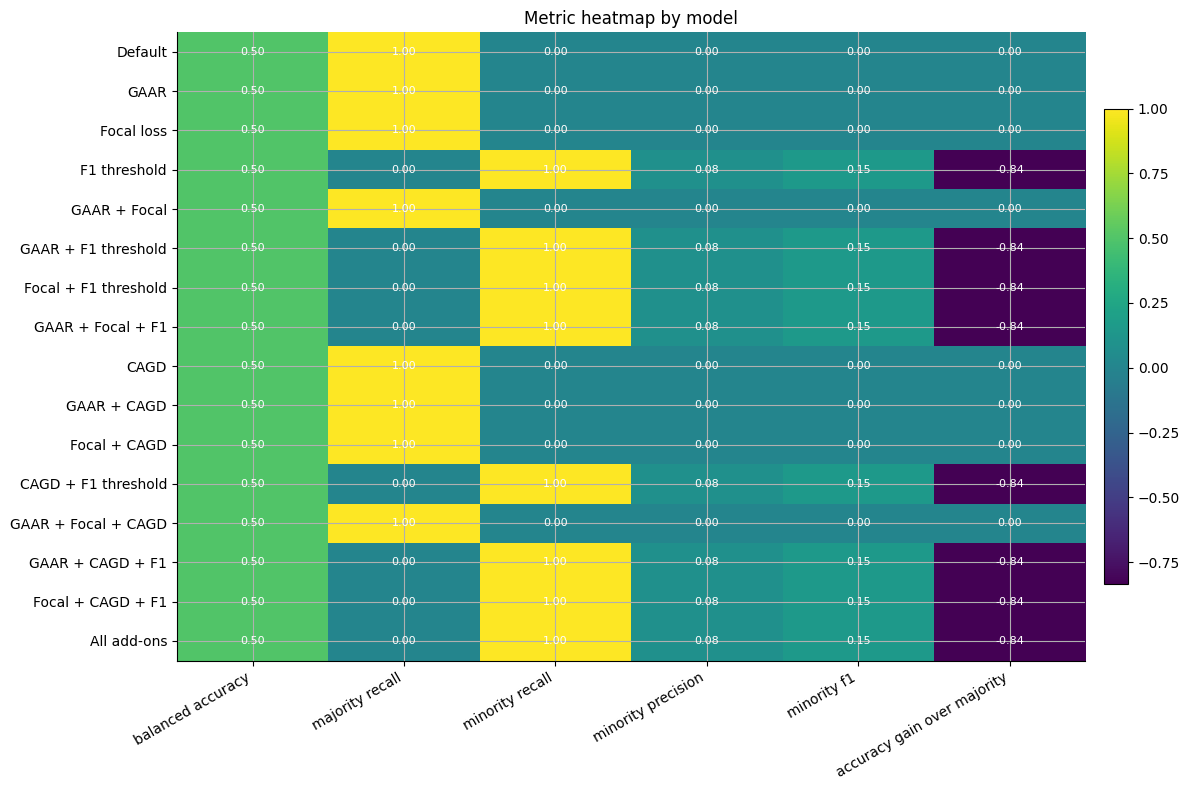

In [30]:
heatmap_metrics = [
    "balanced_accuracy",
    "majority_recall",
    "minority_recall",
    "minority_precision",
    "minority_f1",
    "accuracy_gain_over_majority",
]

heatmap_df = successful_results.set_index("display_name")[heatmap_metrics]
heatmap_df = heatmap_df.sort_values("balanced_accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
image = ax.imshow(heatmap_df.values, aspect="auto", cmap="viridis")
ax.set_title("Metric heatmap by model")
ax.set_xticks(np.arange(len(heatmap_metrics)))
ax.set_xticklabels([metric.replace("_", " ") for metric in heatmap_metrics], rotation=30, ha="right")
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for row in range(heatmap_df.shape[0]):
    for column in range(heatmap_df.shape[1]):
        ax.text(column, row, f"{heatmap_df.iloc[row, column]:.2f}", ha="center", va="center", color="white", fontsize=8)

fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()

## 7. Matrizes de Confusão dos Modelos Mais Relevantes

A matriz de confusão torna o compromisso mais fácil de ver:

- `TP`: exemplos da classe minoritária previstos correctamente como positivos.
- `FN`: exemplos da classe minoritária que o modelo falhou.
- `FP`: exemplos da classe maioritária previstos incorrectamente como positivos.
- `TN`: exemplos da classe maioritária previstos correctamente como negativos.

Neste problema, falhar demasiados positivos é mau, mas prever positivo para quase tudo também não é uma solução útil.

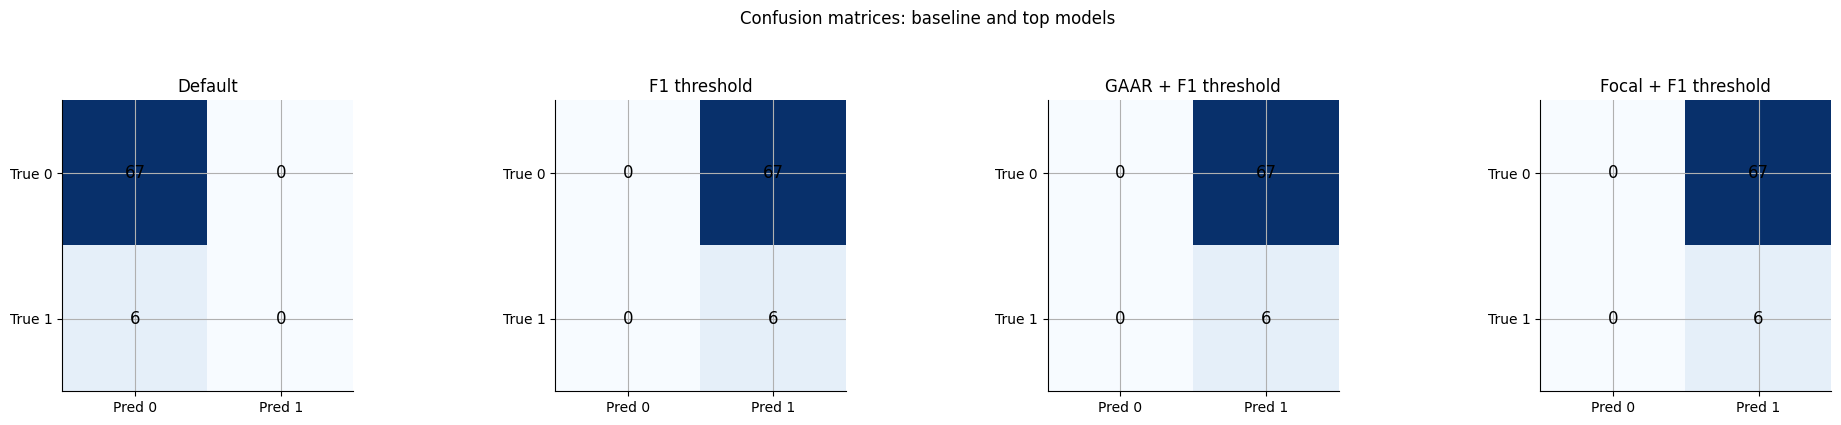

In [31]:
def confusion_matrix_for(model_name):
    row = successful_results[successful_results["model"] == model_name].iloc[0]
    return np.array([[row["tn"], row["fp"]], [row["fn"], row["tp"]]], dtype=int)

selected_models = ["default"]
selected_models.extend(
    successful_results.sort_values(["balanced_accuracy", "minority_f1"], ascending=False)["model"]
    .head(3)
    .tolist()
)
selected_models = list(dict.fromkeys(selected_models))

fig, axes = plt.subplots(1, len(selected_models), figsize=(5 * len(selected_models), 4))
if len(selected_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, selected_models):
    display_name = successful_results.loc[successful_results["model"] == model_name, "display_name"].iloc[0]
    matrix = confusion_matrix_for(model_name)
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(display_name)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["True 0", "True 1"])

    for row in range(2):
        for column in range(2):
            ax.text(column, row, str(matrix[row, column]), ha="center", va="center", fontsize=12)

fig.suptitle("Confusion matrices: baseline and top models", y=1.05)
plt.tight_layout()
plt.show()

## 8. Diferença Face à Baseline

Esta tabela subtrai o modelo default a cada modelo com add-ons. Valores positivos significam que o add-on teve melhor resultado nesta divisão.

In [32]:
def add_default_differences(results):
    default_row = results[results["model"] == "default"].iloc[0]
    comparison = results.copy()
    for metric in ["balanced_accuracy", "minority_recall", "minority_f1", "accuracy_gain_over_majority"]:
        comparison[f"delta_{metric}"] = comparison[metric] - default_row[metric]
    return comparison

comparison_df = add_default_differences(successful_results)
comparison_columns = [
    "display_name",
    "delta_balanced_accuracy",
    "delta_minority_recall",
    "delta_minority_f1",
    "delta_accuracy_gain_over_majority",
]

display(
    comparison_df.sort_values("delta_balanced_accuracy", ascending=False)[comparison_columns].round(4)
)

,display_name,delta_balanced_accuracy,delta_minority_recall,delta_minority_f1,delta_accuracy_gain_over_majority
0,Default,0.0,0.0,0.0000,0.0000
1,GAAR,0.0,0.0,0.0000,0.0000
2,Focal loss,0.0,0.0,0.0000,0.0000
3,F1 threshold,0.0,1.0,0.1519,-0.8356
4,GAAR + Focal,0.0,0.0,0.0000,0.0000
5,GAAR + F1 threshold,0.0,1.0,0.1519,-0.8356
6,Focal + F1 threshold,0.0,1.0,0.1519,-0.8356
7,GAAR + Focal + F1,0.0,1.0,0.1519,-0.8356
8,CAGD,0.0,0.0,0.0000,0.0000
9,GAAR + CAGD,0.0,0.0,0.0000,0.0000


## 9. Guardar a Corrida

Guardo os objectos principais para poder voltar a abrir esta corrida mais tarde sem treinar todos os modelos outra vez.

In [33]:
artifact = {
    "dataset_name": DATASET_NAME,
    "dataset": df,
    "target_counts": target_counts.to_dict(),
    "split_summary": split_summary_df,
    "splits": splits,
    "model_overview": model_overview,
    "results": results_df,
    "trained_models": trained_models,
    "predictions": predictions,
    "probabilities": probabilities,
    "random_state": RANDOM_STATE,
    "learning_rate": LEARNING_RATE,
    "iterations": ITERATIONS,
}

with ARTIFACT_PATH.open("wb") as file:
    pickle.dump(artifact, file)

print(f"Saved artifact to: {ARTIFACT_PATH}")
print(f"Successful models: {len(trained_models)} / {len(model_specs)}")

Saved artifact to: /home/bruno-zabot/Studies/MachineLearning/assignment/outputs/notebook_runs/df18_logistic_regression_run.pkl
Successful models: 16 / 16


## 10. Notas para a Discussão

Este notebook usa apenas um conjunto de dados e uma divisão, por isso trato-o como uma corrida de exemplo. O script é onde verifico se os mesmos padrões se mantêm em vários conjuntos de dados e várias seeds.

Para a discussão, estas são as principais perguntas a que responderia:

- Os add-ons melhoraram o recall ou o F1 da classe minoritária em comparação com o modelo default?
- Essa melhoria veio acompanhada de uma grande perda no recall da classe maioritária?
- Qual é a combinação de add-ons com o melhor compromisso geral?
- Os resultados daqui batem certo com os do script maior?